## 留意事項

* 本資料は教育・情報提供を目的とした検証資料であり、特定の暗号資産や取引手法の売買を推奨するものではありません。
* バックテストは過去データに基づく試算であり、将来の成果を保証しません。
*  手数料・スリッページ・ETF Flowの公表時刻を完全には再現していません。

# 20260716 初心者botter会 ロング判定bot 〜ETF編〜

**問い**  
ETFフローを用いて、BTCのロングに適した市場環境を判定できるか

**今回の主役**  
`FBTC Flow > 0`

**現時点の結論**  
バックテストの内部整合性は高く、有望な研究候補。ただし、10hでのデータ取得可能性は未確認であり、実運用可能なBOTとはまだ扱わない。


![botterkai](botterkai.jpeg)

### 配布ファイル

- `20260716_初心者botter会_ロング判定bot.ipynb`
- `long_judgement_bot_event_data.csv`
- `botterkai.jpeg`
- `market_score_decomposition_0702.png`

CSV 1ファイルを読み込んで、表とグラフを再現します。


In [1]:
from pathlib import Path
import math
import tempfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display, Image

warnings.filterwarnings("ignore")

BASE = Path.cwd().resolve()
CSV_NAME = "long_judgement_bot_event_data.csv"
CSV_CANDIDATES = [BASE / CSV_NAME, BASE / "event_notebook_20260716_long_judgement_bot" / CSV_NAME]
CSV_PATH = next((p for p in CSV_CANDIDATES if p.exists()), None)
if CSV_PATH is None:
    tried = "\n".join(str(p) for p in CSV_CANDIDATES)
    raise FileNotFoundError(f"{CSV_NAME} が見つかりません。Notebookと同じフォルダに置いてください。\n{tried}")

OUT_DIR = BASE / "event_outputs_20260716_long_judgement_bot"
OUT_DIR.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 170
plt.rcParams["axes.unicode_minus"] = False
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
for font in ["Hiragino Sans", "YuGothic", "Meiryo", "AppleGothic", "DejaVu Sans"]:
    if font in available_fonts:
        plt.rcParams["font.family"] = [font]
        break

COLORS = {
    "HODL": "#171717",
    "FBTC Flow only": "#d64545",
    "FBTC & MA50": "#2878b5",
    "FBTC & Premium": "#8e44ad",
    "Low priority": "#9aa0a6",
}

def pct(x, digits=1):
    return f"{x:+.{digits}f}%"

print("Input:", CSV_PATH.name)
print("Output folder:", OUT_DIR.name)

Input: long_judgement_bot_event_data.csv
Output folder: event_outputs_20260716_long_judgement_bot


## 今日の流れ

```text
7/2 Market Score
↓
利益の主因を分解
↓
ETF Flowが中心に見える
↓
All ETF / IBIT / FBTC / IBIT+FBTC を比較
↓
FBTC Flow only を研究候補にする
↓
他指標を足す価値を確認
↓
最後に、公開時刻問題を確認
```


## 〜共通の売買ルール〜

判定の流れ:

1. ETF対象日の翌日10:00 UTC（日本時間19:00）に条件を判定する
2. 条件を満たす場合: BTCを買う。すでに持っている場合はそのまま保有する
3. 条件を満たさない場合: 持っているBTCをすべて売る。持っていない場合は何もしない
4. 次の判定時刻までは、BTCを保有または売却した状態を維持する

※その時刻までにETF Flowを取得できると仮定しています。

共通条件:

- BTCを買う、保有する、すべて売る、のいずれか（ショートなし）
- 手数料は片道5bps
- レバレッジなし
- 損切り・利確なし

例:

```text
FBTC Flow only
FBTC Flow > 0   : BTCを買う／そのまま保有する
FBTC Flow <= 0  : 持っているBTCをすべて売る／何も持たず待つ

FBTC & MA50
FBTC Flow > 0 かつ BTC価格 > MA50 : BTCを買う／保有する
どちらかを満たさない              : 持っているBTCをすべて売る

FBTC & Premium
FBTC Flow > 0 かつ Coinbase Premium > 0 : BTCを買う／保有する
どちらかを満たさない                     : 持っているBTCをすべて売る
```


## 1. データ

期間: 2024年1月〜2026年6月

使うもの:

- BTC価格
- ETF Flow
- Coinbase Premium
- Funding / OI / Macro / Trend
- point-in-time監視ログの準備状況

このNotebookは最新API取得はしません。


In [2]:
raw = pd.read_csv(CSV_PATH)
print("Rows:", len(raw))
print("Sections:", sorted(raw["section"].dropna().unique()))

equity = raw[raw["section"] == "equity"].copy()
equity["timestamp"] = pd.to_datetime(equity["timestamp"], utc=True)
equity = equity.set_index("timestamp").sort_index()

obs = raw[raw["section"] == "observation"].copy()
obs["observation_date"] = pd.to_datetime(obs["observation_date"], utc=True)
obs["execution_timestamp"] = pd.to_datetime(obs["execution_timestamp"], utc=True)
obs = obs.set_index("observation_date").sort_index()

summary = raw[raw["section"] == "summary"].copy()
etf_family = raw[raw["section"] == "etf_family"].copy()
etf_family_curve = raw[raw["section"] == "etf_family_curve"].copy()
etf_family_curve["timestamp"] = pd.to_datetime(etf_family_curve["timestamp"], utc=True)
etf_family_curve = etf_family_curve.set_index("timestamp").sort_index()
defensive_pct = raw[raw["section"] == "defensive_percentile"].copy()
threshold = raw[raw["section"] == "threshold_delay"].copy()
momentum_reg = raw[raw["section"] == "momentum_regression"].copy()
momentum_quad = raw[raw["section"] == "momentum_quadrant"].copy()
pit_ready = raw[raw["section"] == "point_in_time_readiness"].copy()
pit_timing = raw[raw["section"] == "point_in_time_timing"].copy()
pit_timing["flow_date"] = pd.to_datetime(pit_timing["flow_date"])

print("Period:", equity.index.min(), "to", equity.index.max())
print("ETF observations:", len(obs))
display(obs[["fbtc_flow_usd", "all_etf_flow_usd", "fbtc_flow_positive", "premium_positive", "ma50_positive"]].head())

Rows: 43338
Sections: ['defensive_percentile', 'equity', 'etf_family', 'etf_family_curve', 'momentum_quadrant', 'momentum_regression', 'observation', 'point_in_time_readiness', 'point_in_time_timing', 'summary', 'threshold_delay']


Period: 2024-01-12 11:00:00+00:00 to 2026-06-18 10:00:00+00:00
ETF observations: 609


,fbtc_flow_usd,all_etf_flow_usd,fbtc_flow_positive,premium_positive,ma50_positive
observation_date,,,,,
2024-01-11 00:00:00+00:00,227000000.0,655300000.0,1.0,1.0,0.0
2024-01-12 00:00:00+00:00,195300000.0,203000000.0,1.0,0.0,0.0
2024-01-16 00:00:00+00:00,102000000.0,-52700000.0,1.0,0.0,0.0
2024-01-17 00:00:00+00:00,358100000.0,453800000.0,1.0,0.0,0.0
2024-01-18 00:00:00+00:00,177900000.0,-126600000.0,1.0,0.0,0.0


## 2. 7/2に分析したMarket Scoreからなぜ分解したのか

7/2は4指標のMarket Scoreを使いました。

```text
ETF Flow
Coinbase Premium
ETF Flow 5観測日平均
Funding
```

次に見るべき問い:

```text
本当に4指標が効いたのか？
ETF Flowだけで説明できるのか？
```


![7/2 Market Score decomposition](market_score_decomposition_0702.png)

前回の4象限では、ETF Flowが主因に見えました。  
ここから、ETF Flow自体を分解します。


## 3. ETF Flow

比較対象:

```text
All ETF
IBIT
FBTC
IBIT+FBTC
```

共通ルールで比較します。


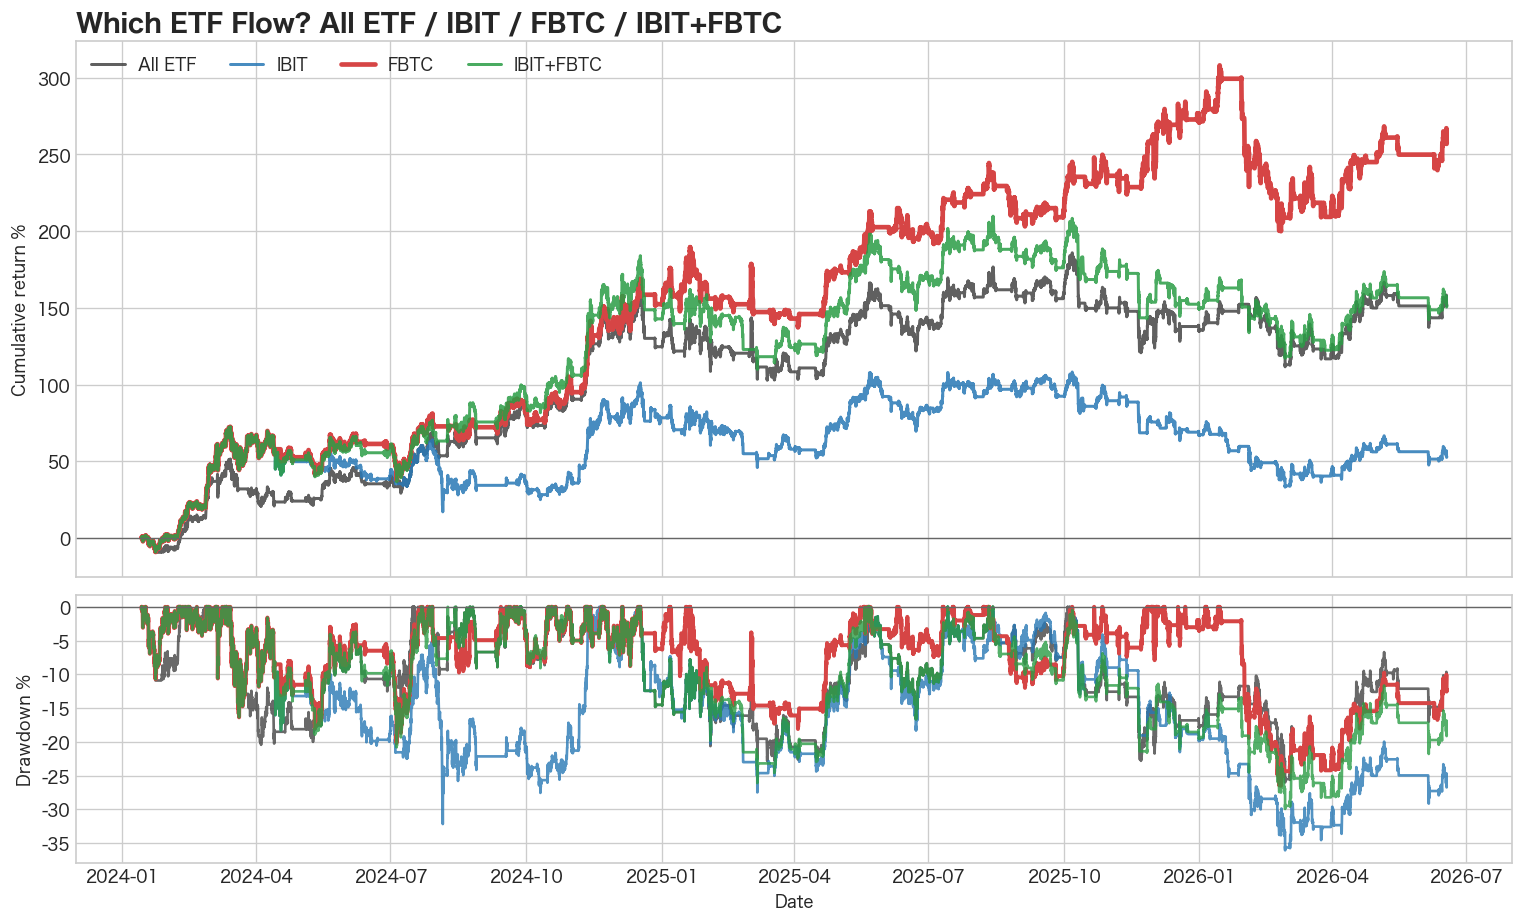

In [3]:
family = etf_family[
    (etf_family["signal_rule"] == "Flow only")
    & (etf_family["delay_hours"].isin([10, 24]))
    & (etf_family["period"].isin(["Full common", "2025 onward"]))
].copy()

show = family[
    (family["delay_hours"] == 10)
    & (family["period"].isin(["Full common", "2025 onward"]))
].copy()
variant_order = ["All ETF", "IBIT", "FBTC", "IBIT+FBTC"]
show["flow_variant"] = pd.Categorical(show["flow_variant"], variant_order, ordered=True)
show = show.sort_values(["period", "flow_variant"])

family_colors = {
    "All ETF": "#444444",
    "IBIT": "#2878b5",
    "FBTC": "#d64545",
    "IBIT+FBTC": "#2a9d45",
}

fig, axes = plt.subplots(2, 1, figsize=(12.8, 7.8), sharex=True, gridspec_kw={"height_ratios": [2.0, 1.0]})
for variant in variant_order:
    eq = etf_family_curve[f"{variant}__equity"].dropna()
    ret_pct = (eq - 1.0) * 100
    axes[0].plot(
        ret_pct.index,
        ret_pct,
        label=variant,
        color=family_colors[variant],
        lw=2.8 if variant == "FBTC" else 1.8,
        alpha=1.0 if variant == "FBTC" else 0.85,
    )
    dd_pct = etf_family_curve[f"{variant}__drawdown"].dropna() * 100
    axes[1].plot(
        dd_pct.index,
        dd_pct,
        label=variant,
        color=family_colors[variant],
        lw=2.4 if variant == "FBTC" else 1.6,
        alpha=1.0 if variant == "FBTC" else 0.8,
    )

axes[0].axhline(0, color="#666666", lw=0.8)
axes[1].axhline(0, color="#666666", lw=0.8)
axes[0].set_title("Which ETF Flow? All ETF / IBIT / FBTC / IBIT+FBTC", loc="left", fontsize=15, weight="bold")
axes[0].set_ylabel("Cumulative return %")
axes[1].set_ylabel("Drawdown %")
axes[1].set_xlabel("Date")
axes[0].legend(loc="upper left", ncol=4)
fig.tight_layout()
plt.show()

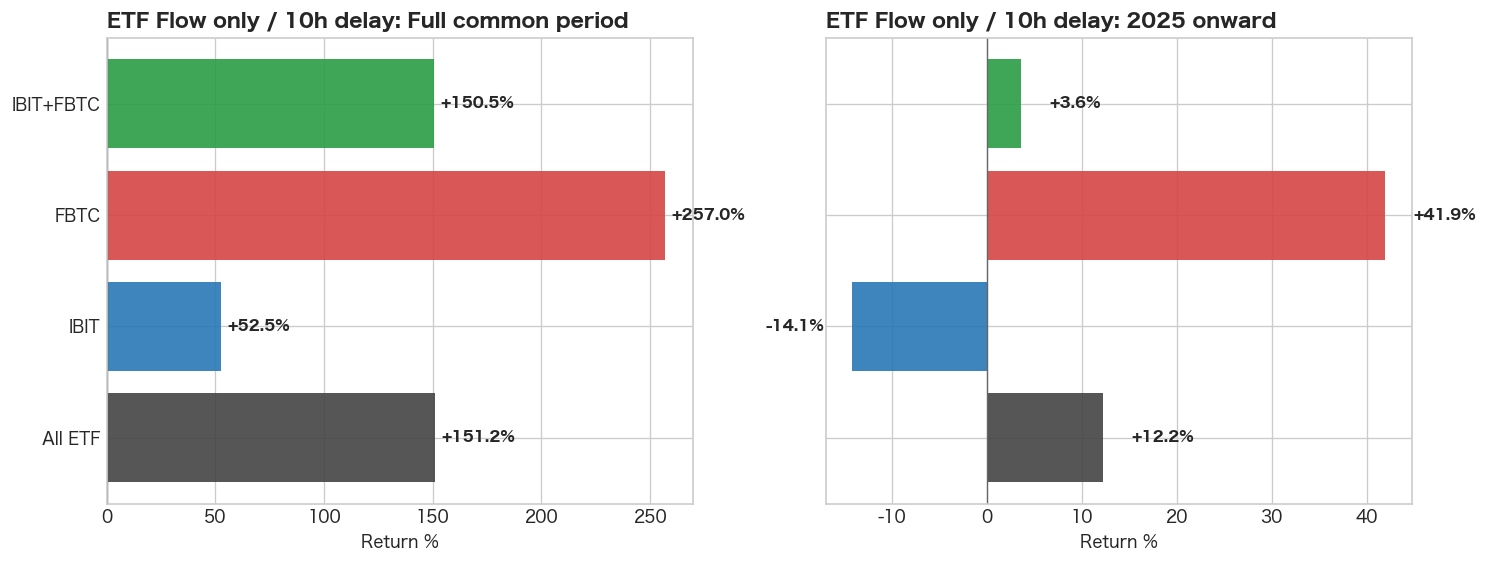

,period,flow_variant,delay_hours,total_return_pct,max_drawdown_pct,sharpe_hourly,calendar_exposure_pct,position_changes
21931,2025 onward,All ETF,10.0,12.22,-26.01,0.41,55.26,125.0
21943,2025 onward,IBIT,10.0,-14.15,-36.06,-0.17,56.77,111.0
21955,2025 onward,FBTC,10.0,41.93,-26.50,0.97,45.13,149.0
21967,2025 onward,IBIT+FBTC,10.0,3.56,-29.93,0.23,55.45,121.0
21930,Full common,All ETF,10.0,151.20,-26.01,1.24,60.38,186.0
21942,Full common,IBIT,10.0,52.54,-36.06,0.65,64.45,156.0
21954,Full common,FBTC,10.0,256.96,-26.50,1.69,55.76,198.0
21966,Full common,IBIT+FBTC,10.0,150.54,-29.93,1.20,65.12,156.0


In [4]:
compact = show.pivot(index="flow_variant", columns="period", values="total_return_pct").reindex(variant_order)
compact = compact.rename(columns={"Full common": "Full common", "2025 onward": "2025+"})
dd_compact = show[show["period"] == "Full common"].set_index("flow_variant").reindex(variant_order)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=True)
for ax, period, title in [
    (axes[0], "Full common", "Full common period"),
    (axes[1], "2025 onward", "2025 onward"),
]:
    sub = show[show["period"] == period].sort_values("flow_variant")
    colors = [family_colors[str(x)] for x in sub["flow_variant"]]
    bars = ax.barh(sub["flow_variant"].astype(str), sub["total_return_pct"], color=colors, alpha=0.9)
    ax.axvline(0, color="#666666", lw=0.8)
    ax.set_title(f"ETF Flow only / 10h delay: {title}", loc="left", fontsize=12, weight="bold")
    ax.set_xlabel("Return %")
    ax.invert_yaxis()
    for bar, value in zip(bars, sub["total_return_pct"]):
        ax.text(value + (3 if value >= 0 else -3), bar.get_y()+bar.get_height()/2, f"{value:+.1f}%", va="center", ha="left" if value >= 0 else "right", fontsize=9, weight="bold")
fig.tight_layout()
plt.show()

display(
    show[["period", "flow_variant", "delay_hours", "total_return_pct", "max_drawdown_pct", "sharpe_hourly", "calendar_exposure_pct", "position_changes"]]
    .round(2)
)

結果:

- この期間では `FBTC Flow only` が最も強い
- ただし、結果を見た後にFBTCを選んでいる
- なので「確定ロジック」ではなく「研究候補」
- このセクションの `Full common` はETF間比較の共通期間（2024-01-14 01:00〜2026-06-18 00:00 UTC）
- 次節以降の `Full` は拡張期間（2024-01-12 11:00〜2026-06-18 10:00 UTC）であり、開始・終了境界が異なるため数値を直接比較しない

ここから先は、FBTCを軸に深掘りします。


## 4. 今回の研究候補: FBTC Flow only

ルール:

```text
FBTC Flow > 0  → BTCロング
FBTC Flow <= 0 → BTCを売却して待機
```

- ロングのみ
- ショートなし
- レバレッジなし
- 損切り・利確なし

注: この節の `Full` は拡張期間です。前節のETF間比較は `Full common` という別期間です。


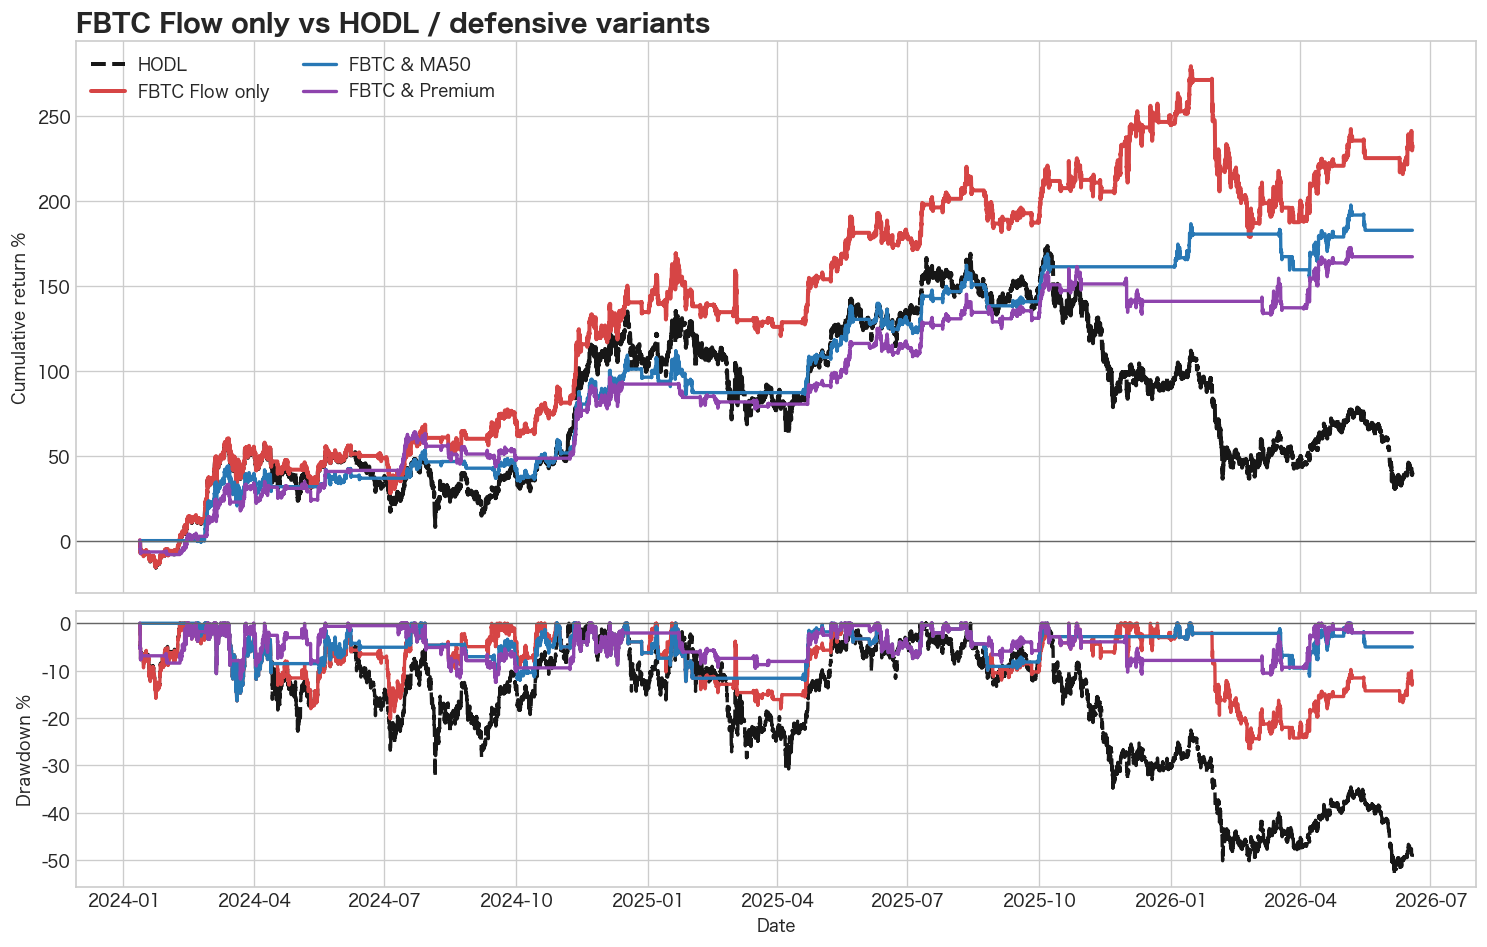

In [5]:
curve_rules = ["HODL", "FBTC Flow only", "FBTC & MA50", "FBTC & Premium"]
fig, axes = plt.subplots(2, 1, figsize=(12.5, 8.0), sharex=True, gridspec_kw={"height_ratios": [2.0, 1.0]})

for rule in curve_rules:
    col = f"{rule}__net_equity"
    series = (equity[col] - 1.0) * 100
    axes[0].plot(
        series.index,
        series,
        label=rule,
        color=COLORS.get(rule, "#777777"),
        linestyle="--" if rule == "HODL" else "-",
        lw=2.4 if rule in ["HODL", "FBTC Flow only"] else 2.0,
    )

for rule in curve_rules:
    col = f"{rule}__net_equity"
    eq = equity[col].dropna()
    dd = eq / eq.cummax() - 1.0
    axes[1].plot(
        dd.index,
        dd * 100,
        label=rule,
        color=COLORS.get(rule, "#777777"),
        linestyle="--" if rule == "HODL" else "-",
        lw=2.0,
    )

axes[0].axhline(0, color="#666666", lw=0.8)
axes[1].axhline(0, color="#666666", lw=0.8)
axes[0].set_title("FBTC Flow only vs HODL / defensive variants", loc="left", fontsize=15, weight="bold")
axes[0].set_ylabel("Cumulative return %")
axes[1].set_ylabel("Drawdown %")
axes[1].set_xlabel("Date")
axes[0].legend(loc="upper left", ncol=2)
fig.tight_layout()
plt.show()

In [6]:
table_rules = ["FBTC Flow only", "FBTC & MA50", "FBTC & Premium", "HODL"]
display_cols = ["rule", "decision", "full_return_pct", "full_dd_pct", "full_sharpe", "return_2025_pct", "dd_2025_pct", "sharpe_2025"]
display(
    summary[summary["rule"].isin(table_rules)][display_cols]
    .set_index("rule")
    .loc[table_rules]
    .round(2)
)

,decision,full_return_pct,full_dd_pct,full_sharpe,return_2025_pct,dd_2025_pct,sharpe_2025
rule,,,,,,,
FBTC Flow only,Core candidate,231.22,-26.50,1.60,41.27,-26.50,0.96
FBTC & MA50,Defensive reference,182.57,-16.36,1.76,44.06,-12.29,1.41
FBTC & Premium,Defensive reference,167.01,-12.46,1.77,39.00,-10.94,1.33
HODL,Benchmark,39.23,-52.88,0.52,-31.34,-52.88,-0.35


読み方:

- `FBTC Flow only`: リターン重視
- `FBTC & MA50`: DDを下げる候補
- `FBTC & Premium`: DDを下げる候補
- `HODL`: 比較用


## 5. 他の指標を足す価値はあるか

FBTC Flowに追加したもの:

- Coinbase Premium
- Funding
- OI
- MA50 / MA100 / MA200 / 30日モメンタム
- VIX / DXY / 米10年金利 / Nasdaq

ここでも売買ルールは同じです。変えるのは追加条件です。

見るポイント:

```text
複雑にして、主役を置き換えるほど良くなるか？
```


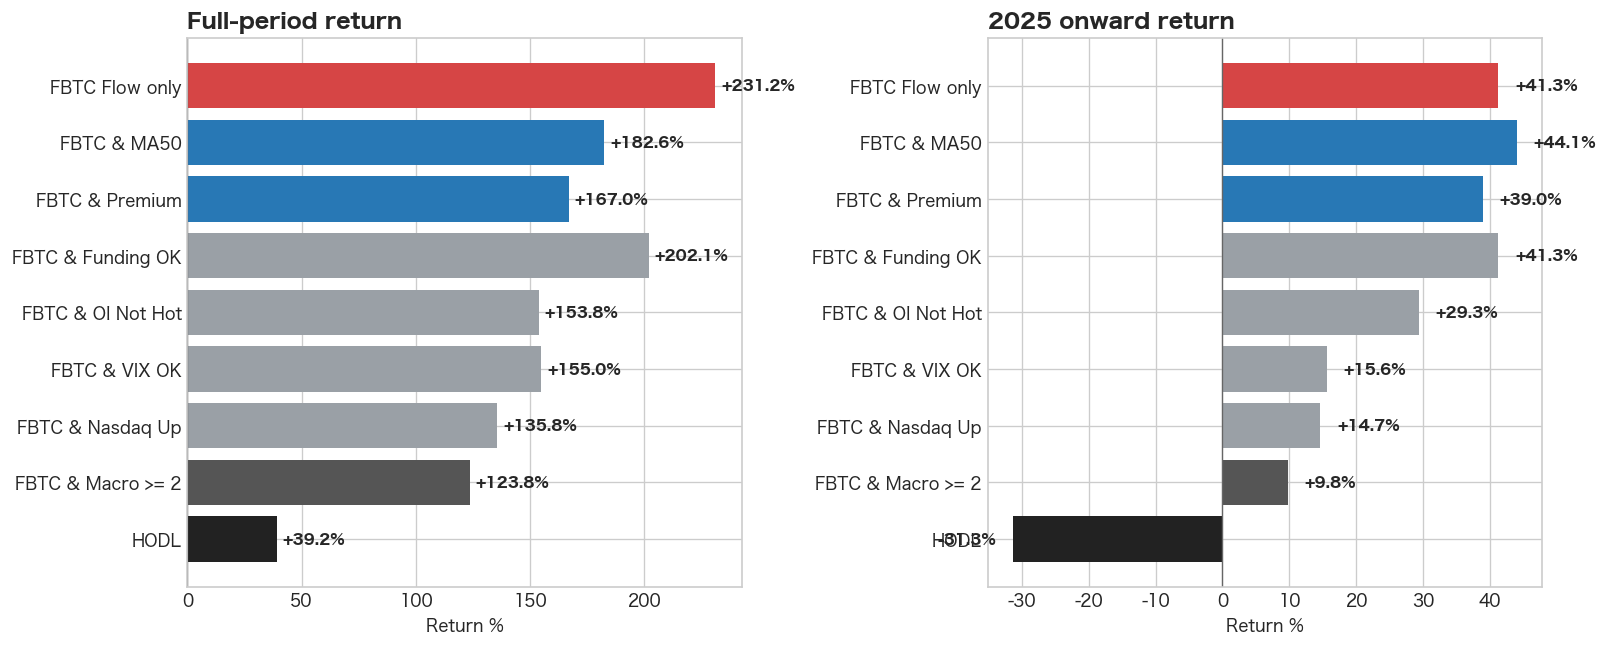

,rule,decision,note
0,FBTC Flow only,Core candidate,"Most promising, but not proven. Threshold 0M a..."
1,FBTC & MA50,Defensive reference,"DD improves, but Step36 shows timing inside Fl..."
2,FBTC & Premium,Defensive reference,"DD improves, but Step36 does not support extra..."
3,FBTC & Funding OK,Low priority,Mostly inactive in this sample; should not be ...
4,FBTC & OI Not Hot,Low priority,Lower return and limited risk improvement.
5,FBTC & VIX OK,Low priority,Macro overlays remove too many good Flow+ oppo...
6,FBTC & Nasdaq Up,Low priority,Improves DD somewhat but 2025+ contribution is...
7,FBTC & Macro >= 2,Reject for now,Weak return and weak 2025+ result.
8,HODL,Benchmark,Used only as comparison.


In [7]:
order = [
    "FBTC Flow only",
    "FBTC & MA50",
    "FBTC & Premium",
    "FBTC & Funding OK",
    "FBTC & OI Not Hot",
    "FBTC & VIX OK",
    "FBTC & Nasdaq Up",
    "FBTC & Macro >= 2",
    "HODL",
]
work = summary.set_index("rule").loc[order].reset_index()
color_map = {
    "Core candidate": "#d64545",
    "Defensive reference": "#2878b5",
    "Low priority": "#9aa0a6",
    "Reject for now": "#555555",
    "Benchmark": "#222222",
}

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5))
for ax, col, title in [
    (axes[0], "full_return_pct", "Full-period return"),
    (axes[1], "return_2025_pct", "2025 onward return"),
]:
    bars = ax.barh(work["rule"], work[col], color=[color_map.get(x, "#999999") for x in work["decision"]])
    ax.axvline(0, color="#666666", lw=0.8)
    ax.invert_yaxis()
    ax.set_title(title, loc="left", fontsize=13, weight="bold")
    ax.set_xlabel("Return %")
    for bar, value in zip(bars, work[col]):
        ax.text(value + (2.5 if value >= 0 else -2.5), bar.get_y() + bar.get_height()/2, f"{value:+.1f}%", va="center", ha="left" if value >= 0 else "right", fontsize=9, weight="bold")
fig.tight_layout()
plt.show()

display(work[["rule", "decision", "note"]])

見方:

- Funding: この期間ではほぼ効いていない
- OI / Macro: 主役にしにくい
- MA50 / Premium: 防御候補
- ただし、主役はまだFBTC Flow only


## 6. プラス MA50、Premium

DDは下がります。  
ただし、理由は2つありえます。

```text
良いタイミングを選べた
単にロング日数が減った
```

同じロング日数のランダム比較で確認します。


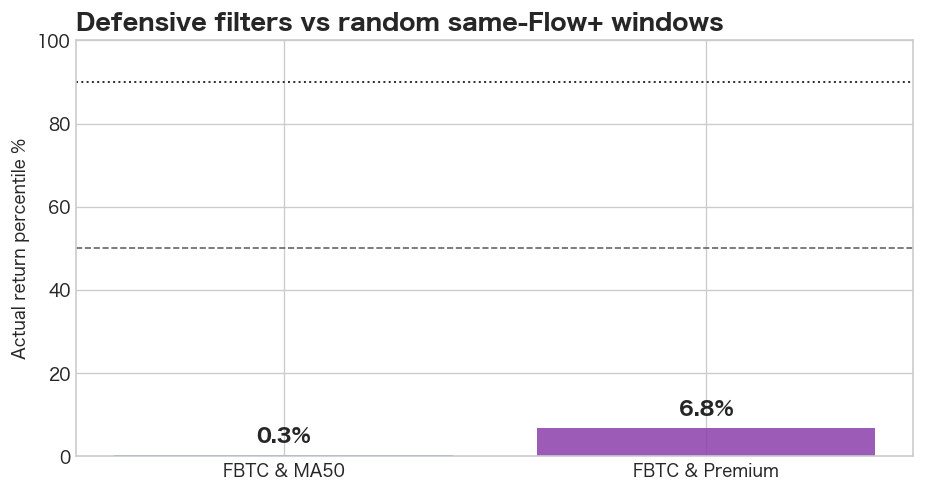

,rule,period,random_contiguous_return_percentile_pct,random_contiguous_median_return_pct
43244,FBTC & MA50,Full,0.3,328.30
43246,FBTC & Premium,Full,6.8,241.25


In [8]:
plot_pct = defensive_pct[defensive_pct["period"] == "Full"].copy()
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(plot_pct["rule"], plot_pct["random_contiguous_return_percentile_pct"], color=["#2878b5", "#8e44ad"], alpha=0.88)
ax.axhline(50, color="#666666", ls="--", lw=1.0)
ax.axhline(90, color="#333333", ls=":", lw=1.2)
ax.set_ylim(0, 100)
ax.set_title("Defensive filters vs random same-Flow+ windows", loc="left", fontsize=14, weight="bold")
ax.set_ylabel("Actual return percentile %")
for bar, value in zip(bars, plot_pct["random_contiguous_return_percentile_pct"]):
    ax.text(bar.get_x()+bar.get_width()/2, value+2, f"{value:.1f}%", ha="center", va="bottom", fontsize=12, weight="bold")
plt.show()
display(plot_pct[["rule", "period", "random_contiguous_return_percentile_pct", "random_contiguous_median_return_pct"]].round(2))

結果:

- MA50 / PremiumはDDを下げる
- ただし、ランダム比較では上位に来ない
- 追加タイミングエッジは弱い

結論: 防御候補。主役ではない。


## 7. `FBTC Flow > 0` は自然な線引きか

確認すること:

```text
閾値を動かしても成績が残るか
遅延時間を変えても成績が残るか
```

一点だけの最適化なら危険です。


,rule,period,threshold_musd,delay_hours,total_return_pct,max_drawdown_pct,sharpe_hourly
43249,FBTC > +0M | 10h,2025 onward,0.0,10.0,41.27,-26.50,0.96
43251,FBTC > +0M | 24h,2025 onward,0.0,24.0,16.67,-27.74,0.51
43253,FBTC > +0M | 48h,2025 onward,0.0,48.0,3.19,-35.80,0.22
43255,FBTC > +50M | 10h,2025 onward,50.0,10.0,29.05,-13.85,0.91
43257,FBTC > +50M | 24h,2025 onward,50.0,24.0,1.36,-14.95,0.15
43259,FBTC > +50M | 48h,2025 onward,50.0,48.0,-5.88,-27.33,-0.07
43248,FBTC > +0M | 10h,Full,0.0,10.0,231.22,-26.50,1.60
43250,FBTC > +0M | 24h,Full,0.0,24.0,206.12,-27.74,1.49
43252,FBTC > +0M | 48h,Full,0.0,48.0,108.57,-35.80,1.03
43254,FBTC > +50M | 10h,Full,50.0,10.0,121.94,-19.76,1.38


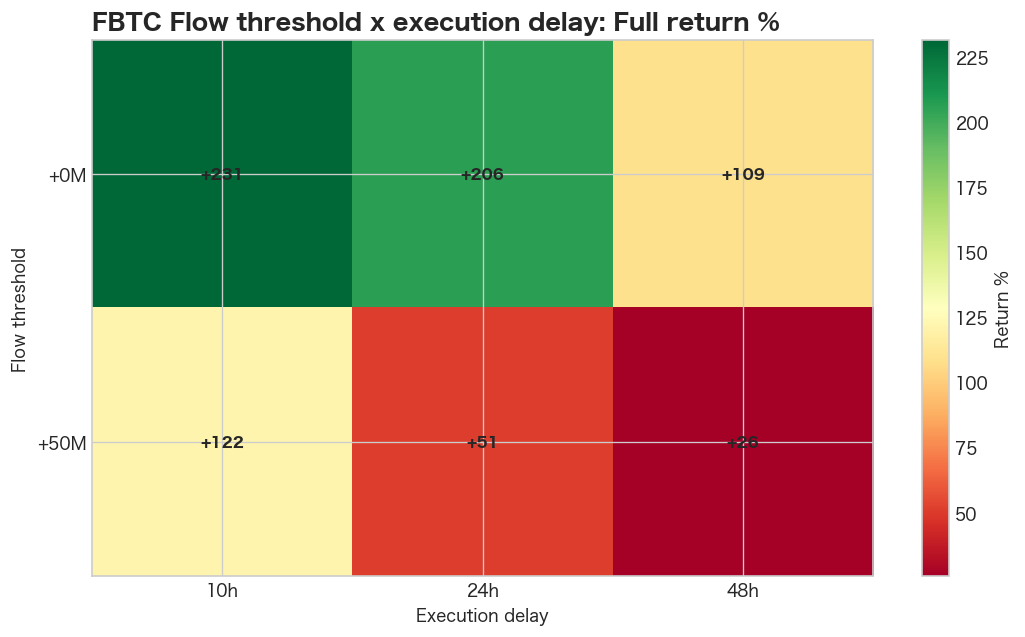

In [9]:
td = threshold.copy()
td = td[td["period"].isin(["Full", "2025 onward"])].copy()
selected = td[(td["threshold_musd"].isin([0, 50])) & (td["delay_hours"].isin([10, 24, 48]))]
display(
    selected[["rule", "period", "threshold_musd", "delay_hours", "total_return_pct", "max_drawdown_pct", "sharpe_hourly"]]
    .sort_values(["period", "threshold_musd", "delay_hours"])
    .round(2)
)

full = td[td["period"] == "Full"].pivot(index="threshold_musd", columns="delay_hours", values="total_return_pct").sort_index()
fig, ax = plt.subplots(figsize=(10.5, 5.8))
im = ax.imshow(full.to_numpy(), cmap="RdYlGn", aspect="auto")
ax.set_xticks(np.arange(len(full.columns)))
ax.set_xticklabels([f"{int(x)}h" for x in full.columns])
ax.set_yticks(np.arange(len(full.index)))
ax.set_yticklabels([f"{x:+.0f}M" for x in full.index])
ax.set_title("FBTC Flow threshold x execution delay: Full return %", loc="left", fontsize=14, weight="bold")
ax.set_xlabel("Execution delay")
ax.set_ylabel("Flow threshold")
for i, idx in enumerate(full.index):
    for j, col in enumerate(full.columns):
        v = full.loc[idx, col]
        ax.text(j, i, f"{v:+.0f}", ha="center", va="center", fontsize=9, weight="bold")
fig.colorbar(im, ax=ax, label="Return %")
plt.show()

結果:

- `> 0M / 10h` が強い
- `> 0M / 24h` でも残る
- `> 50M` はDD低下、リターン低下
- 配布CSVにある閾値は `0M` と `+50M` の2点だけ
- マイナス閾値の良否は、このデータからは判断できない

したがって `Flow > 0` は自然な候補だが、閾値の頑健性を十分に確認したとはまだ言えない。


### 7.1 ゼロフロー日の扱い

609観測日のうち63日（約10%）がFBTC Flowちょうど0です。次の3仕様を比較します。

- `> 0`: 現行仕様。ゼロなら待機
- `>= 0`: ゼロでもロング
- `zero = hold prior`: ゼロなら直前ポジションを維持


In [10]:
cost_per_side = 5.0 / 10_000

# HODL系列からBTCの時間次グロスリターンを復元します。
# HODLの初回約定とCSV先頭時刻だけ、計上済みの5bpsを戻します。
btc_hourly_return = equity["HODL__net_return"].copy()
first_hodl = btc_hourly_return.first_valid_index()
btc_hourly_return.loc[first_hodl] += cost_per_side
first_equity = equity.index[0]
btc_hourly_return.loc[first_equity] = equity.loc[first_equity, "FBTC Flow only__net_return"] + cost_per_side

def hourly_position(signal):
    events = obs.reset_index()[["execution_timestamp"]].copy()
    events["signal"] = np.asarray(signal, dtype=float)
    hourly = pd.merge_asof(
        equity.reset_index()[["timestamp"]].sort_values("timestamp"),
        events.sort_values("execution_timestamp"),
        left_on="timestamp",
        right_on="execution_timestamp",
        direction="backward",
        allow_exact_matches=False,  # 10:00確定なら10:00→11:00バーから適用
    )
    return hourly.set_index("timestamp")["signal"].fillna(0.0)

carry_signal = []
state = 0.0
for flow in obs["fbtc_flow_usd"]:
    if flow > 0:
        state = 1.0
    elif flow < 0:
        state = 0.0
    carry_signal.append(state)

zero_signals = {
    "> 0 (current)": obs["fbtc_flow_usd"].gt(0).astype(float),
    ">= 0": obs["fbtc_flow_usd"].ge(0).astype(float),
    "zero = hold prior": pd.Series(carry_signal, index=obs.index),
}

zero_rows = []
for zero_rule, signal in zero_signals.items():
    position = hourly_position(signal)
    changes = position.diff().abs()
    changes.iloc[0] = abs(position.iloc[0])
    net_return = position * btc_hourly_return - changes * cost_per_side
    for period, start in [("Full extended", None), ("2025 onward", pd.Timestamp("2025-01-01", tz="UTC"))]:
        r = net_return if start is None else net_return.loc[start:]
        p = position.loc[r.index]
        c = changes.loc[r.index]
        curve = (1.0 + r).cumprod()
        drawdown = curve / curve.cummax() - 1.0
        zero_rows.append({
            "zero_rule": zero_rule,
            "period": period,
            "return_pct": (curve.iloc[-1] - 1.0) * 100,
            "max_drawdown_pct": drawdown.min() * 100,
            "sharpe_hourly": r.mean() / r.std(ddof=1) * np.sqrt(8760),
            "position_changes": int(c.sum()),
            "exposure_pct": p.mean() * 100,
        })

zero_robustness = pd.DataFrame(zero_rows)
display(zero_robustness.round(2))


,zero_rule,period,return_pct,max_drawdown_pct,sharpe_hourly,position_changes,exposure_pct
0,> 0 (current),Full extended,231.22,-26.50,1.60,199,55.86
1,> 0 (current),2025 onward,41.27,-26.50,0.96,149,45.18
2,>= 0,Full extended,239.65,-26.56,1.49,197,65.88
3,>= 0,2025 onward,32.67,-26.56,0.73,157,57.92
4,zero = hold prior,Full extended,206.76,-26.50,1.45,169,61.04
5,zero = hold prior,2025 onward,28.31,-26.50,0.70,135,50.99


読み方:

- Full extendedでは3仕様ともプラスで、結論は直ちには崩れない
- 2025 onwardでは現行の `> 0` が最も強く、ゼロ日の扱いが成績に影響する
- `>= 0` と「ゼロなら継続」は別仕様なので混同しない
- この比較も事後的な頑健性確認であり、新しい最適仕様を選ぶためのものではない


## 8. 短期モメンタム

懸念:

```text
Flowが効いているのではなく、
上がった後に買っているだけでは？
```

1日〜20日のBTCリターンを入れて確認します。


,period,model,term,coef_pct,t_nw_lag5,p_norm_approx,n
43261,Full,flow_dummy_only,flow_positive,0.7984,3.6915,0.0002,603.0
43269,Full,flow_dummy_plus_momentum_1_3_5_10_20d,flow_positive,0.8708,3.7661,0.0002,603.0
43276,Full,flow_amount_plus_momentum_1_3_5_10_20d,flow_usd_bn,2.4034,2.4500,0.0143,603.0
43283,2025 onward,flow_dummy_only,flow_positive,0.6284,2.4847,0.0130,364.0
43291,2025 onward,flow_dummy_plus_momentum_1_3_5_10_20d,flow_positive,0.7786,2.8024,0.0051,364.0
43298,2025 onward,flow_amount_plus_momentum_1_3_5_10_20d,flow_usd_bn,2.3870,2.1272,0.0334,364.0


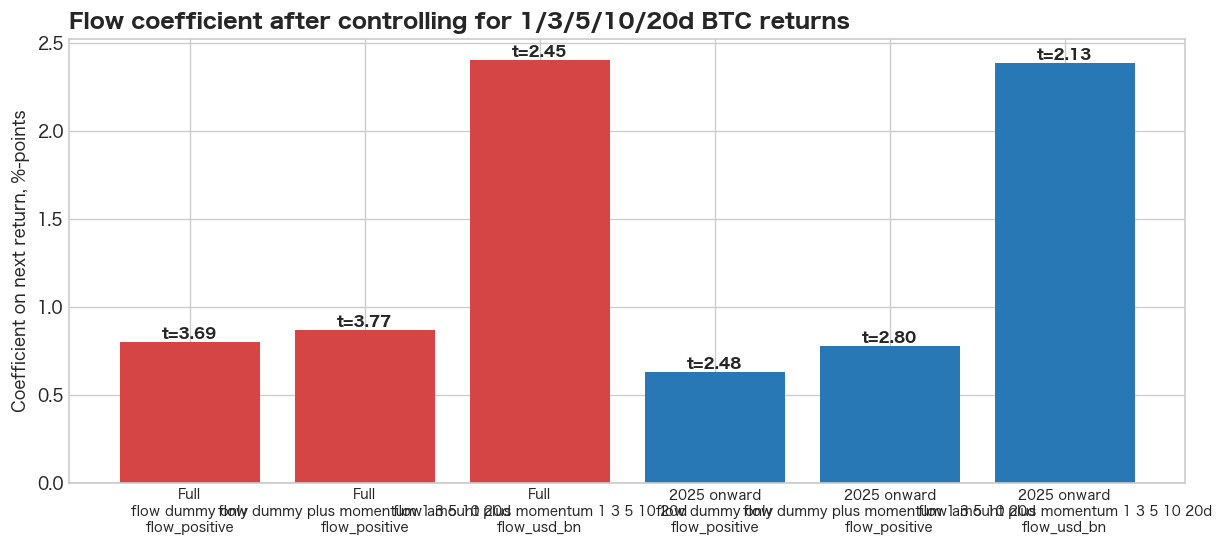

In [11]:
focus = momentum_reg[
    momentum_reg["term"].isin(["flow_positive", "flow_usd_bn"])
    & momentum_reg["model"].isin([
        "flow_dummy_only",
        "flow_dummy_plus_momentum_1_3_5_10_20d",
        "flow_amount_plus_momentum_1_3_5_10_20d",
    ])
].copy()
focus["coef_pct"] = focus["coef"] * 100
display(focus[["period", "model", "term", "coef_pct", "t_nw_lag5", "p_norm_approx", "n"]].round(4))

fig, ax = plt.subplots(figsize=(12, 4.8))
labels = focus["period"] + "\n" + focus["model"].str.replace("_", " ", regex=False) + "\n" + focus["term"]
bars = ax.bar(labels, focus["coef_pct"], color=["#d64545" if p == "Full" else "#2878b5" for p in focus["period"]])
ax.axhline(0, color="#666666", lw=0.8)
ax.set_title("Flow coefficient after controlling for 1/3/5/10/20d BTC returns", loc="left", fontsize=13, weight="bold")
ax.set_ylabel("Coefficient on next return, %-points")
ax.tick_params(axis="x", labelsize=8)
for bar, (_, row) in zip(bars, focus.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f"t={row['t_nw_lag5']:.2f}", ha="center", va="bottom", fontsize=9, weight="bold")
plt.show()

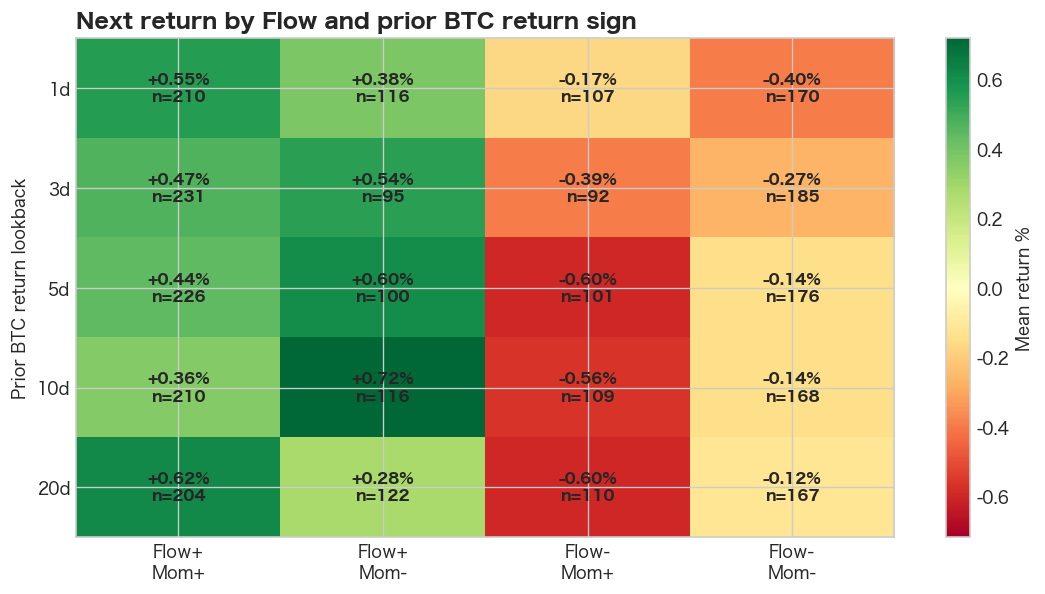

In [12]:
quad = momentum_quad.copy()
quad["mean_return_pct"] = quad["mean_return"] * 100
heat = quad.pivot(index="lookback_days", columns="quadrant", values="mean_return_pct").loc[
    [1,3,5,10,20], ["Flow+ Mom+", "Flow+ Mom-", "Flow- Mom+", "Flow- Mom-"]
]
counts = quad.pivot(index="lookback_days", columns="quadrant", values="n").loc[heat.index, heat.columns]

fig, ax = plt.subplots(figsize=(11, 5.4))
mx = np.nanmax(np.abs(heat.to_numpy()))
im = ax.imshow(heat.to_numpy(), cmap="RdYlGn", vmin=-mx, vmax=mx, aspect="auto")
ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels(["Flow+\nMom+", "Flow+\nMom-", "Flow-\nMom+", "Flow-\nMom-"])
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels([f"{int(x)}d" for x in heat.index])
ax.set_title("Next return by Flow and prior BTC return sign", loc="left", fontsize=13, weight="bold")
ax.set_ylabel("Prior BTC return lookback")
for i, idx in enumerate(heat.index):
    for j, col in enumerate(heat.columns):
        v = heat.loc[idx, col]
        n = int(counts.loc[idx, col])
        ax.text(j, i, f"{v:+.2f}%\nn={n}", ha="center", va="center", fontsize=9, weight="bold")
fig.colorbar(im, ax=ax, label="Mean return %")
plt.show()

結果:

- 短期リターンを入れてもFlow係数は残る
- 完全な証明ではない
- ただし、単なる短期モメンタムだけではなさそう

注意: 回帰の目的変数 `next_observation_return` は固定24時間先ではなく、現在のETF観測時刻から次のETF観測時刻までのリターンです。休日をまたぐため24〜96時間と期間が変わります。補助分析として解釈し、固定24時間先リターンでも別途確認する必要があります。


## 9. 公開時間のチェック（継続中）

バックテストでは後から確定したETF Flowを使っています。

実運用で必要な確認:

```text
何時にデータが公開されたのか？
後から修正されていないか？
```


,item,value,required,status,note
43324,Forward polls,149,ongoing,OK,The Block polling log
43325,First-seen flow dates,7,>= 60,NOT_READY,too few for performance backtest
43326,Observation calendar span,10,>= 90 days,NOT_READY,monitoring period is still short
43327,Locked point-in-time signals,6,>= 60,NOT_READY,signal_events can later replace historical ass...
43328,Value revisions observed,0,tracked,OK,"0 means no corrections observed yet, not proof..."
43329,Local BTC price covers forward signals,False,True,NOT_READY,"price_end=2026-06-18 15:00:00+00:00, latest_si..."
43330,Official Fidelity PDF reconstruction,1,ongoing,OK,"validates definition, but current-date coverag..."


,check,count,total
0,First-seen by target (lag <= 0h),1,7
1,First-seen within 2h after target,3,7
2,First-seen within 24h after target,5,7
3,Signal locked by target (lag <= 0h),0,7
4,Signal locked within 24h after target,5,7


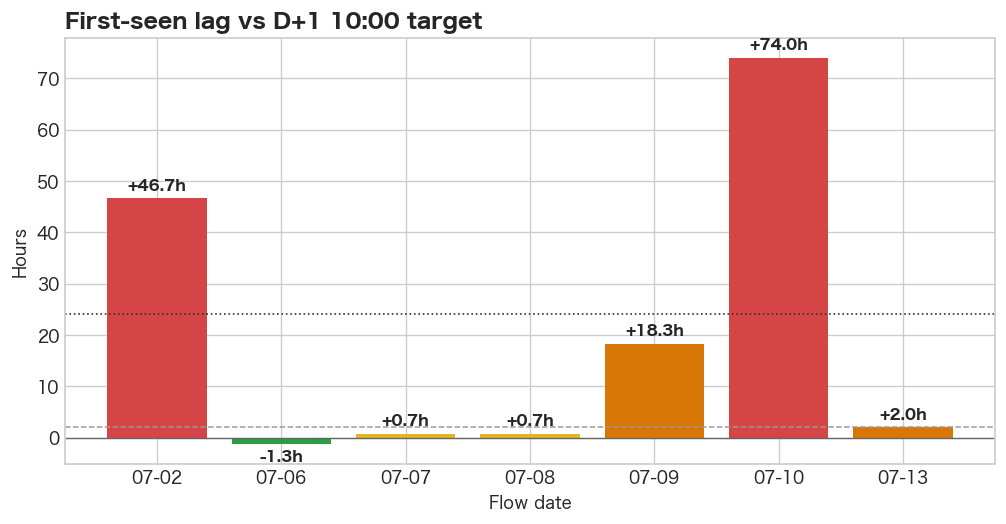

In [13]:
display(pit_ready[["item", "value", "required", "status", "note"]])

pit_checks = pd.DataFrame({
    "check": [
        "First-seen by target (lag <= 0h)",
        "First-seen within 2h after target",
        "First-seen within 24h after target",
        "Signal locked by target (lag <= 0h)",
        "Signal locked within 24h after target",
    ],
    "count": [
        int((pit_timing["first_seen_lag_hours"] <= 0).sum()),
        int((pit_timing["first_seen_lag_hours"] <= 2).sum()),
        int((pit_timing["first_seen_lag_hours"] <= 24).sum()),
        int((pit_timing["signal_lock_lag_hours"] <= 0).sum()),
        int((pit_timing["signal_lock_lag_hours"] <= 24).sum()),
    ],
})
pit_checks["total"] = len(pit_timing)
display(pit_checks)

fig, ax = plt.subplots(figsize=(10, 4.6))
bars = ax.bar(
    pit_timing["flow_date"].dt.strftime("%m-%d"),
    pit_timing["first_seen_lag_hours"],
    color=["#2a9d45" if x <= 0 else "#e6b422" if x <= 2 else "#d97706" if x <= 24 else "#d64545" for x in pit_timing["first_seen_lag_hours"]],
)
ax.axhline(0, color="#666666", lw=0.8)
ax.axhline(2, color="#999999", lw=0.9, ls="--")
ax.axhline(24, color="#333333", lw=1.0, ls=":")
ax.set_title("First-seen lag vs D+1 10:00 target", loc="left", fontsize=13, weight="bold")
ax.set_ylabel("Hours")
ax.set_xlabel("Flow date")
for bar, value in zip(bars, pit_timing["first_seen_lag_hours"]):
    ax.text(bar.get_x()+bar.get_width()/2, value + (1 if value >= 0 else -1), f"{value:+.1f}h", ha="center", va="bottom" if value >= 0 else "top", fontsize=9, weight="bold")
plt.show()

現時点:

- 監視ログは動いているが、まだ7件だけ
- first-seenがD+1 10:00までに間に合ったのは1/7件
- 2時間以内なら3/7件、24時間以内なら5/7件
- signal lockがD+1 10:00までに完了した例は0/7件
- 数十分〜数時間の遅れにはポーリング時刻の影響も含まれ得るため、これは配信元の公開時刻そのものとは限らない
- 件数が少なく、実運用成績としては扱わない

次は、初回取得ログを貯める段階。


## 10. 現時点の仕様

```text
対象: BTCUSDT
方向: ロングのみ

シグナル:
FBTC Flow > 0 ならBTCを買う／そのまま保有する
FBTC Flow <= 0 なら持っているBTCをすべて売る／何も持たず待つ

バックテストの実行シナリオ:
10h = 楽観ケース（取得可能性は未確認）
24h = 感応度ケース
48h = ストレスケース
実運用時刻 = point-in-timeログ確定後に決める

コスト:
片道5bps
```



## 11. BTCチャート上でロング候補期間を確認

ここまでは売買損益を中心に見てきました。ここでは、`FBTC Flow > 0` がBTCチャート上のどの期間を「BTCを保有する候補」と判定したのかを可視化します。

- 緑背景: FBTC Flow > 0。BTCを買う／保有する候補期間
- 灰色背景: FBTC Flow <= 0。BTCをすべて売って待つ期間
- ▲: BTCを買う判定へ切り替わった時点
- ▼: 持っているBTCをすべて売る判定へ切り替わった時点

これはルールで定義した候補レジームであり、将来の上昇を正しく予測できると証明したものではありません。


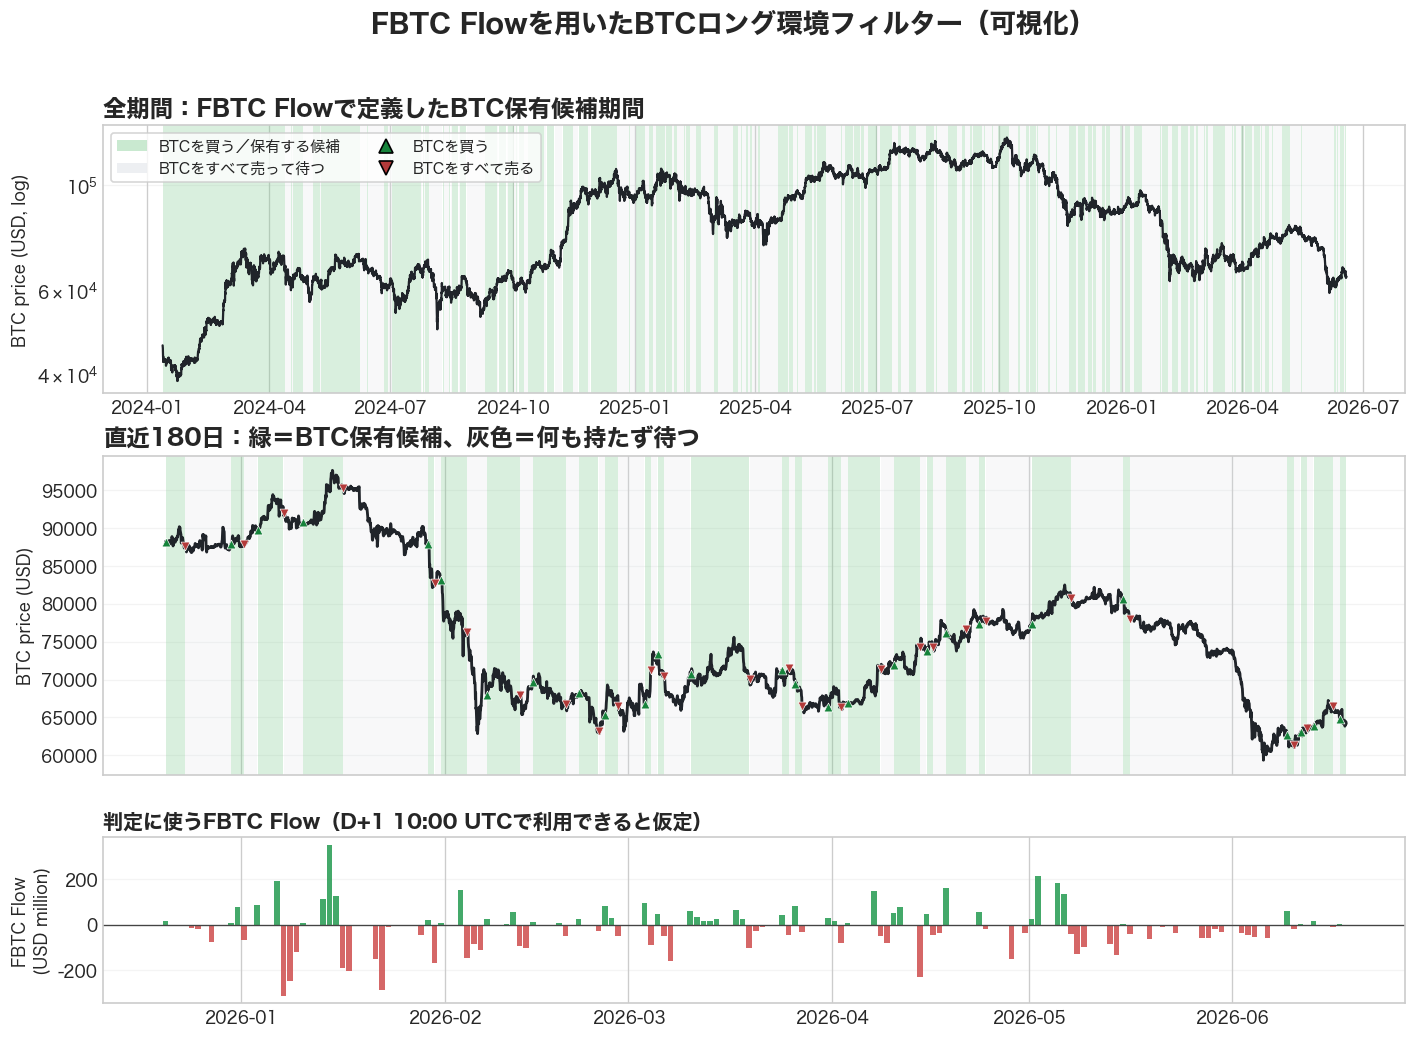

In [14]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

regime_cost = 5.0 / 10_000

# HODL系列から、コスト控除前のBTC時間次リターンを復元します。
regime_btc_return = equity["HODL__net_return"].copy()
regime_first_hodl = regime_btc_return.first_valid_index()
regime_btc_return.loc[regime_first_hodl] += regime_cost
regime_first_hour = equity.index[0]
regime_btc_return.loc[regime_first_hour] = equity.loc[regime_first_hour, "FBTC Flow only__net_return"] + regime_cost

regime_anchor_time = obs["execution_timestamp"].iloc[0]
regime_anchor_price = float(obs["btc_price_at_execution"].iloc[0])
regime_btc_price = regime_anchor_price * (1.0 + regime_btc_return).cumprod()
regime_price_timeline = pd.concat([
    pd.Series([regime_anchor_price], index=pd.DatetimeIndex([regime_anchor_time])),
    regime_btc_price,
]).sort_index()
regime_position = equity["FBTC Flow only__position"].fillna(0.0)

def add_regime_background(ax, position, start=None, end=None):
    work = position.copy()
    if start is not None:
        work = work.loc[start:]
    if end is not None:
        work = work.loc[:end]
    groups = work.ne(work.shift()).cumsum()
    for _, segment in work.groupby(groups):
        is_long_candidate = float(segment.iloc[0]) == 1.0
        color = "#79c98b" if is_long_candidate else "#d9dde3"
        alpha = 0.28 if is_long_candidate else 0.18
        ax.axvspan(segment.index[0], segment.index[-1], color=color, alpha=alpha, lw=0)

regime_end = regime_btc_price.index.max()
regime_zoom_start = regime_end - pd.Timedelta(days=180)
regime_entries = regime_position.diff().fillna(regime_position.iloc[0]).gt(0)
regime_exits = regime_position.diff().fillna(regime_position.iloc[0]).lt(0)

fig = plt.figure(figsize=(14, 9.5))
grid = fig.add_gridspec(3, 1, height_ratios=[1.05, 1.25, 0.65], hspace=0.25)
ax_full = fig.add_subplot(grid[0])
ax_zoom = fig.add_subplot(grid[1])
ax_flow = fig.add_subplot(grid[2], sharex=ax_zoom)

add_regime_background(ax_full, regime_position)
ax_full.plot(regime_btc_price.index, regime_btc_price, color="#20242a", lw=1.35)
ax_full.set_yscale("log")
ax_full.set_ylabel("BTC price (USD, log)")
ax_full.set_title("全期間：FBTC Flowで定義したBTC保有候補期間", loc="left", fontsize=14, weight="bold")
ax_full.grid(axis="y", alpha=0.22)

zoom_price = regime_btc_price.loc[regime_zoom_start:regime_end]
zoom_position = regime_position.loc[regime_zoom_start:regime_end]
add_regime_background(ax_zoom, zoom_position, regime_zoom_start, regime_end)
ax_zoom.plot(zoom_price.index, zoom_price, color="#20242a", lw=1.7)
entry_index = regime_entries.loc[regime_zoom_start:regime_end]
entry_index = entry_index[entry_index].index
exit_index = regime_exits.loc[regime_zoom_start:regime_end]
exit_index = exit_index[exit_index].index
ax_zoom.scatter(entry_index, regime_btc_price.loc[entry_index], marker="^", s=28, color="#16833b", edgecolor="white", linewidth=0.4, zorder=5)
ax_zoom.scatter(exit_index, regime_btc_price.loc[exit_index], marker="v", s=28, color="#b33a3a", edgecolor="white", linewidth=0.4, zorder=5)
ax_zoom.set_ylabel("BTC price (USD)")
ax_zoom.set_title("直近180日：緑＝BTC保有候補、灰色＝何も持たず待つ", loc="left", fontsize=14, weight="bold")
ax_zoom.grid(axis="y", alpha=0.22)
ax_zoom.tick_params(axis="x", labelbottom=False)

flow_zoom = obs[(obs["execution_timestamp"] >= regime_zoom_start) & (obs["execution_timestamp"] <= regime_end)].copy()
flow_zoom["flow_musd"] = flow_zoom["fbtc_flow_usd"] / 1_000_000
flow_colors = np.where(flow_zoom["flow_musd"] > 0, "#2a9d55", "#d05252")
ax_flow.bar(flow_zoom["execution_timestamp"], flow_zoom["flow_musd"], width=0.85, color=flow_colors, alpha=0.88)
ax_flow.axhline(0, color="#444444", lw=0.8)
ax_flow.set_ylabel("FBTC Flow\n(USD million)")
ax_flow.set_title("判定に使うFBTC Flow（D+1 10:00 UTCで利用できると仮定）", loc="left", fontsize=12, weight="bold")
ax_flow.grid(axis="y", alpha=0.20)

legend_items = [
    Patch(facecolor="#79c98b", alpha=0.40, label="BTCを買う／保有する候補"),
    Patch(facecolor="#d9dde3", alpha=0.45, label="BTCをすべて売って待つ"),
    Line2D([0], [0], marker="^", color="none", markerfacecolor="#16833b", markersize=8, label="BTCを買う"),
    Line2D([0], [0], marker="v", color="none", markerfacecolor="#b33a3a", markersize=8, label="BTCをすべて売る"),
]
ax_full.legend(handles=legend_items, loc="upper left", ncol=2, frameon=True, fontsize=9)
fig.suptitle("FBTC Flowを用いたBTCロング環境フィルター（可視化）", fontsize=16, weight="bold", y=0.98)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()


### 固定24時間先リターンで簡易確認

単に戦略損益を見るだけでなく、各判定時刻から24時間後のBTCリターンを比較します。これにより、ロング候補期間の直後が、待機期間の直後より相対的に良かったかを確認します。


In [15]:
regime_eval = obs.reset_index()[["observation_date", "execution_timestamp", "fbtc_flow_usd", "btc_price_at_execution"]].copy()
regime_eval["price_24h_later"] = regime_price_timeline.reindex(
    pd.DatetimeIndex(regime_eval["execution_timestamp"] + pd.Timedelta(hours=24))
).to_numpy()
regime_eval["forward_24h_return"] = regime_eval["price_24h_later"] / regime_eval["btc_price_at_execution"] - 1.0
regime_eval["regime"] = np.where(
    regime_eval["fbtc_flow_usd"] > 0,
    "BTCを買う／保有する候補",
    "BTCをすべて売って待つ",
)

regime_stats = (
    regime_eval.groupby("regime", sort=False)["forward_24h_return"]
    .agg(
        observations="count",
        mean_return="mean",
        median_return="median",
        positive_rate=lambda x: (x > 0).mean(),
        worst_return="min",
    )
)
for col in ["mean_return", "median_return", "positive_rate", "worst_return"]:
    regime_stats[col] = regime_stats[col] * 100
regime_stats = regime_stats.rename(columns={
    "mean_return": "24h平均リターン%",
    "median_return": "24h中央値%",
    "positive_rate": "24h上昇率%",
    "worst_return": "24hワースト%",
})
display(regime_stats.round(2))

long_mean = regime_stats.loc["BTCを買う／保有する候補", "24h平均リターン%"]
wait_mean = regime_stats.loc["BTCをすべて売って待つ", "24h平均リターン%"]
print(f"24h平均リターン差（候補 - 待機）: {long_mean - wait_mean:+.2f}ポイント")


,observations,24h平均リターン%,24h中央値%,24h上昇率%,24hワースト%
regime,,,,,
BTCを買う／保有する候補,332,0.24,0.25,57.83,-7.54
BTCをすべて売って待つ,277,-0.10,0.04,51.99,-10.54


24h平均リターン差（候補 - 待機）: +0.34ポイント


読み方:

- BTCチャート上で、どこを保有候補と判定したかを直接確認できる
- 固定24時間先の平均リターンと上昇率を、候補期間と待機期間で同じ基準により比較できる
- 緑の期間にも下落はあり、灰色の期間にも上昇はある。完全な上昇・下落判定ではない
- 同じデータを見た後の分析であり、事後選択、公開時刻、期間外再現性の問題は残る

結論: `FBTC Flow > 0` はBTCを保有する環境を選別する指標候補だが、実用的なロング環境判定と呼ぶにはpoint-in-timeデータと期間外検証が必要。


## 12. まとめ

- 7/2 Market Scoreを分解
- 主因はETF Flowに見えた
- ETF別ではFBTCが最も強かった
- ただし事後選択バイアスあり
- Premium / MA50は防御候補
- Funding / OI / Macroは低優先度
- 10h遅延は楽観仮定で、公開・取得時刻は未解決
- ゼロフロー仕様を変えてもFull extendedのプラスは残るが、2025 onwardは弱くなる
- CSVの閾値は0Mと+50Mだけで、閾値頑健性は限定的
- BTCチャート上の候補期間を可視化し、固定24時間先リターンでも候補期間と待機期間を比較

結論:

```text
計算上は有望な研究候補。
ただし実運用可能なBOTではなく、次はpoint-in-timeログで再検証。
```


## 13. 次にやること

### A. ETFフローを使ったロング相場判定
仮説ベースでの検証から脱却するため、フォワードで実測値を引き続き収集する。

### B. ETF以外の幅広いロング相場判定
ETF Flowに限定せず再現性のあるロング相場判定を探す。

例：
   - 価格・トレンド: MA、モメンタム、ブレイクアウト
   - デリバティブ: Funding、OI、先物ベーシス、清算
   - 現物需給: Coinbase Premium、出来高
   - マクロ・リスク環境: Nasdaq、VIX、DXY

---
## 免責事項

* 本資料は教育・情報提供を目的としており、売買を推奨するものではありません。
* バックテスト結果は過去データに基づく試算であり、将来の成果を保証しません。
* 暗号資産は大きく価格変動する可能性があります。
* 手数料、スリッページ、税金、約定遅延、データ訂正等を完全には反映していません。
* ETF Flowデータは公開時刻・訂正・取得可能性によって実運用上の利用可否が変わります。
* 本資料の利用により生じたいかなる損害についても責任を負いません。
